# Fraud Feature Engineering

## Objective

The objective of this notebook is to extract fraud-related features from job postings based on the project brief.

These features will help the machine learning model identify suspicious job listings by analyzing:

- Fraud Keywords
- Salary Anomalies
- Domain Information
- Text Quality Indicators
- NLP Features

The engineered features will be used for scam detection and risk scoring.

Section 1 : Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import re
from urllib.parse import urlparse

from sklearn.feature_extraction.text import TfidfVectorizer

Loading processed dataset

In [2]:
df = pd.read_csv("../data/processed/processed_dataset.csv")

print(df.shape)

df.head()

(7419, 14)


,City,Listing Type,Field,Job Title,Company Name,Salary/Stipend,Job Description,Location,Posted Date,Experience Level,Application Link,Real/Fake Job,combined_text,label
0,Mumbai,Full-time,Tech,Software Developer,Rao IIT Academy,"₹500,000 - ₹1,200,000",as a software developer at rao iit academy you...,"Mumbai, Maharashtra",2019-05-17T21:02:37Z,Entry Level (0-2 years),https://www.adzuna.in/details/1155088244?utm_m...,Real Job,software developer rao iit academy tech entry ...,0
1,Mumbai,Full-time,Tech,Software Developer,Cere Labs,"₹300,000 - ₹400,000",about us cere labs is a mumbai based company w...,"Mumbai, Maharashtra",2026-01-24T11:20:47Z,Entry Level (0-2 years),https://www.adzuna.in/details/5598463972?utm_m...,Real Job,software developer cere labs tech entry level ...,0
2,Mumbai,Full-time,Tech,Software Developer,Image Media World,"₹500,000 - ₹700,000",job description software developer position ov...,"Mumbai, Maharashtra",2024-04-03T18:05:16Z,Entry Level (0-2 years),https://www.adzuna.in/details/4634583545?utm_m...,Real Job,software developer image media world tech entr...,0
3,Mumbai,Full-time,Tech,Software Developer,Ion,Not specified,job summary writes new software makes modifica...,"Mumbai, Maharashtra",2026-05-17T06:47:16Z,Entry Level (0-2 years),https://www.adzuna.in/details/5731961124?utm_m...,Real Job,software developer ion tech entry level years ...,0
4,Mumbai,Full-time,Tech,Software Developer,Etaash Consultants,"₹300,000 - ₹1,500,000",job opening in it company for angular develope...,"Mumbai, Maharashtra",2021-09-03T01:56:01Z,Entry Level (0-2 years),https://www.adzuna.in/details/2427499903?utm_m...,Real Job,software developer etaash consultants tech ent...,0


Text Quality Features

In [ ]:
df["text_length"] = df["combined_text"].str.len()

df["word_count"] = df["combined_text"].str.split().apply(len)

df["avg_word_length"] = (
    df["combined_text"]
    .str.split()
    .apply(lambda x: np.mean([len(word) for word in x]) if len(x) > 0 else 0)
)

Keyword Risk Score

In [4]:
fraud_keywords = [
    "registration fee",
    "training fee",
    "whatsapp",
    "telegram",
    "earn daily",
    "instant joining",
    "limited seats",
    "quick money",
    "no interview",
    "work from home",
    "guaranteed placement"
]

def keyword_risk_score(text):
    text = str(text).lower()

    score = 0

    for keyword in fraud_keywords:
        if keyword in text:
            score += 1

    return score

df["keyword_risk_score"] = df["combined_text"].apply(
    keyword_risk_score
)

Salary Risk Score

In [5]:
high_risk_words = [
    "earn",
    "daily income",
    "easy money",
    "part time income",
    "guaranteed earnings"
]

def salary_risk(text):

    text = str(text).lower()

    for word in high_risk_words:
        if word in text:
            return 1

    return 0

df["salary_risk_score"] = df["combined_text"].apply(
    salary_risk
)

Domain Features

In [6]:
def extract_domain(url):

    try:
        return urlparse(str(url)).netloc

    except:
        return "unknown"

df["domain"] = df["Application Link"].apply(
    extract_domain
)

Domain Frequency Feature

In [7]:
domain_freq = df["domain"].value_counts()

df["domain_frequency"] = df["domain"].map(
    domain_freq
)

TF-IDF Features

In [8]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_tfidf = tfidf.fit_transform(
    df["combined_text"]
)

print(X_tfidf.shape)

(7419, 5000)


Creating Features Dataset

In [10]:
numerical_features = df[
[
    "text_length",
    "word_count",
    "avg_word_length",
    "keyword_risk_score",
    "salary_risk_score",
    "domain_frequency"
]
]

y = df["label"]

print(numerical_features.shape)

print(y.shape)

(7419, 6)
(7419,)


Saving Artifacts

In [11]:
import joblib

joblib.dump(
    tfidf,
    "../models/tfidf_vectorizer.pkl"
)

df.to_csv(
    "../data/processed/feature_engineered_dataset.csv",
    index=False
)

print("Feature Engineering Completed Successfully")

Feature Engineering Completed Successfully


Validation

In [12]:
df[
[
    "keyword_risk_score",
    "salary_risk_score",
    "domain_frequency"
]
].describe()

,keyword_risk_score,salary_risk_score,domain_frequency
count,7419.000000,7419.000000,7419.000000
mean,0.023184,0.104462,5889.171721
std,0.169059,0.305879,1826.190832
min,0.000000,0.000000,866.000000
25%,0.000000,0.000000,6553.000000
50%,0.000000,0.000000,6553.000000
75%,0.000000,0.000000,6553.000000
max,2.000000,1.000000,6553.000000


Keyword Risk Score Distribution

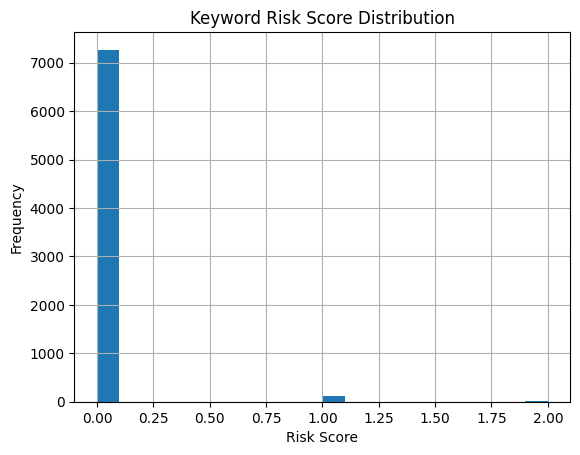

In [13]:
import matplotlib.pyplot as plt

df["keyword_risk_score"].hist(bins=20)

plt.title("Keyword Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")

plt.show()

Real vs Fake Jobs


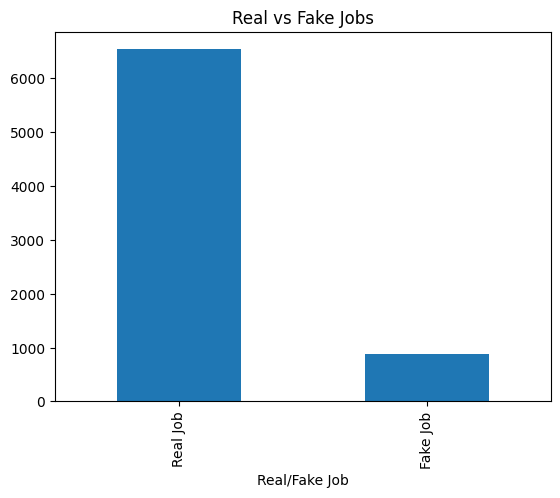

In [14]:
df["Real/Fake Job"].value_counts().plot(kind="bar")

plt.title("Real vs Fake Jobs")

plt.show()

Text Lenght Distribution

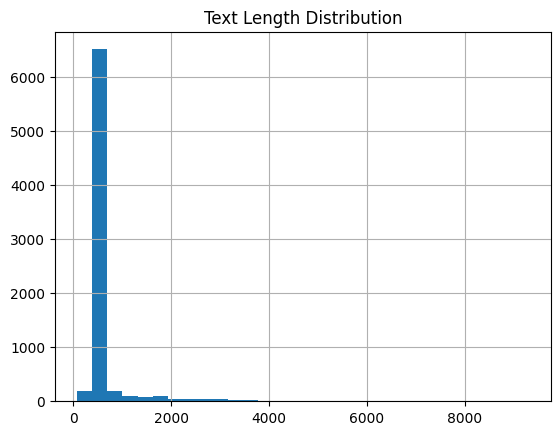

In [15]:
df["text_length"].hist(bins=30)

plt.title("Text Length Distribution")

plt.show()

Top Domains

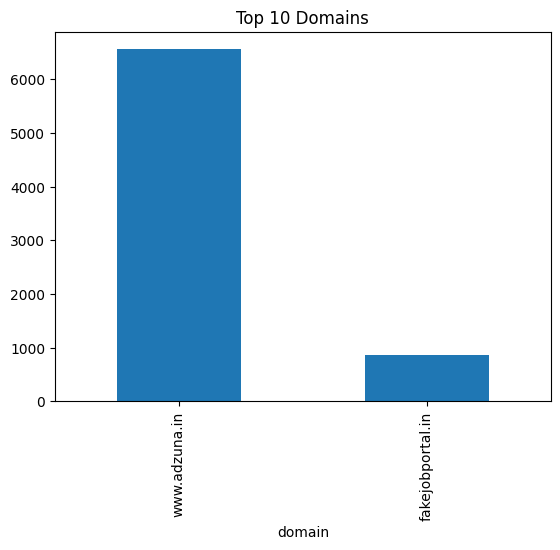

In [16]:
df["domain"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Domains")

plt.show()

Correlation HeatMap

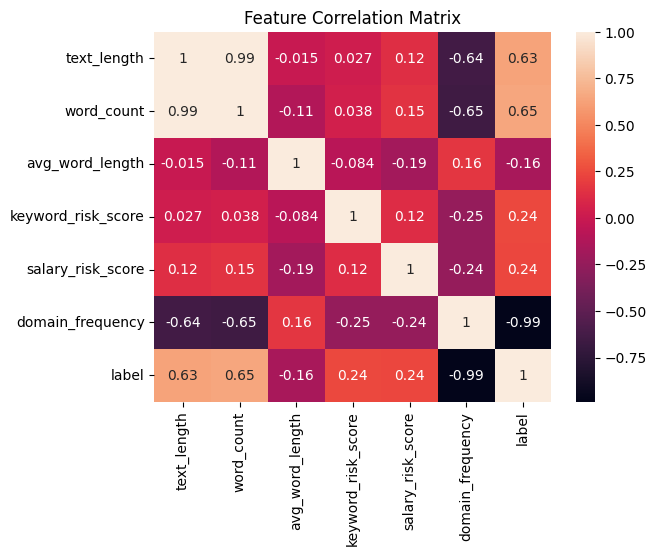

In [17]:
import seaborn as sns

features = [
    "text_length",
    "word_count",
    "avg_word_length",
    "keyword_risk_score",
    "salary_risk_score",
    "domain_frequency",
    "label"
]

sns.heatmap(
    df[features].corr(),
    annot=True
)

plt.title("Feature Correlation Matrix")

plt.show()